# Hybrid CNN-GNN-LSTM Evaluation Notebook

This notebook mirrors `scripts/train_hybrid_cnn_gnn_lstm.py` for maneuver prediction, but it does **not** save a `.pt` checkpoint or summary JSON.

Use it to:
- load all extracted hybrid datasets
- train in-memory
- inspect train/validation curves
- check test accuracy and macro-F1 before deciding whether to save a model later


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

SCRIPTS_DIR = ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from train_hybrid_cnn_gnn_lstm import (
    HybridCNNGNNLSTM,
    HybridManeuverSequenceDataset,
    build_class_weights,
    classification_metrics,
    collate_maneuver_samples,
    evaluate_model,
    group_streams,
    load_schema_labels,
    set_seed,
)

print("Repo root:", ROOT)
print("Torch:", torch.__version__)


Repo root: /home/basudeo/Documents/Thesis
Torch: 2.3.1+cu118


In [2]:
# Configuration
DATASET_ROOT = ROOT / "hybrid_maneuver_dataset"
SEED = 42
PAST_LEN = 10
SCAN_BEAMS = 512
RANGE_CLIP = 30.0
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
MAX_SAMPLES = None  # set to an int for quick tests

CNN_HIDDEN = 96
GRAPH_HIDDEN = 96
FUSION_HIDDEN = 128
LSTM_HIDDEN = 128
LSTM_LAYERS = 1
MSG_PASSES = 2
DROPOUT = 0.1

USE_CPU = False
device = torch.device("cuda" if torch.cuda.is_available() and not USE_CPU else "cpu")
set_seed(SEED)
print("Dataset root:", DATASET_ROOT)
print("Device:", device)


Dataset root: /home/basudeo/Documents/Thesis/hybrid_maneuver_dataset
Device: cuda


In [3]:
# Load and split the hybrid maneuver dataset
labels = load_schema_labels(DATASET_ROOT)
label_to_idx = {label: idx for idx, label in enumerate(labels)}
streams = group_streams(DATASET_ROOT, allowed_labels=set(labels))

dataset = HybridManeuverSequenceDataset(
    streams=streams,
    label_to_idx=label_to_idx,
    past_len=PAST_LEN,
    scan_beams=SCAN_BEAMS,
    range_clip=RANGE_CLIP,
    max_samples=MAX_SAMPLES,
)

total = len(dataset)
train_len = max(1, int(total * TRAIN_RATIO))
val_len = max(1, int(total * VAL_RATIO))
test_len = total - train_len - val_len
if test_len < 1:
    test_len = 1
    if train_len > val_len:
        train_len -= 1
    else:
        val_len -= 1

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len], generator=generator)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_maneuver_samples)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_maneuver_samples)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_maneuver_samples)

train_label_indices = [int(dataset[idx].label.item()) for idx in train_set.indices]
class_weights = build_class_weights(train_label_indices, num_classes=len(labels)).to(device)

print(f"Streams: {len(streams)}")
print(f"Samples: total={total}, train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")
print("Labels:", labels)
print("Class weights:", class_weights.detach().cpu().tolist())


Streams: 8
Samples: total=7726, train=5408, val=1158, test=1160
Labels: ['bootstrap', 'go_to_goal', 'avoid_left', 'avoid_right', 'commit_forward', 'reverse', 'recover', 'reassess', 'arrived', 'stop']
Class weights: [0.0, 0.21640656888484955, 2.9878454208374023, 2.759183645248413, 0.40845921635627747, 45.06666564941406, 38.628570556640625, 3.7296552658081055, 0.5215043425559998, 0.0]


In [4]:
# Build the model
model = HybridCNNGNNLSTM(
    node_dim=14,
    edge_dim=8,
    cnn_hidden=CNN_HIDDEN,
    graph_hidden=GRAPH_HIDDEN,
    fusion_hidden=FUSION_HIDDEN,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    num_classes=len(labels),
    msg_passes=MSG_PASSES,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(weight=class_weights)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")


Model parameters: 283,402


In [5]:
# Train in-memory only. Nothing is saved in this notebook.
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
}

best_val_f1 = float("-inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_count = 0

    for scan_seq, node_seq, edge_seq, labels_batch in train_loader:
        scan_seq = scan_seq.to(device)
        node_seq = node_seq.to(device)
        edge_seq = edge_seq.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        logits = model(scan_seq, node_seq, edge_seq)
        loss = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = labels_batch.size(0)
        running_loss += float(loss.item()) * batch_size
        running_count += int(batch_size)

    train_loss = running_loss / max(running_count, 1)
    val_metrics = evaluate_model(model, val_loader, device, num_classes=len(labels))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"train_loss={train_loss:.5f} "
        f"val_loss={val_metrics['loss']:.5f} "
        f"val_acc={val_metrics['accuracy']:.4f} "
        f"val_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print("Best validation macro-F1:", best_val_f1)


Epoch 01/20 train_loss=2.09622 val_loss=1.82233 val_acc=0.0294 val_f1=0.0057
Epoch 02/20 train_loss=2.06590 val_loss=1.82457 val_acc=0.1865 val_f1=0.0314
Epoch 03/20 train_loss=2.08498 val_loss=1.73798 val_acc=0.4542 val_f1=0.0625
Epoch 04/20 train_loss=2.07946 val_loss=1.86362 val_acc=0.0380 val_f1=0.0073
Epoch 05/20 train_loss=2.07132 val_loss=1.81497 val_acc=0.2461 val_f1=0.0395
Epoch 06/20 train_loss=2.06450 val_loss=1.75188 val_acc=0.4542 val_f1=0.0625
Epoch 07/20 train_loss=2.05478 val_loss=1.76618 val_acc=0.1865 val_f1=0.0314
Epoch 08/20 train_loss=2.07094 val_loss=1.81411 val_acc=0.0294 val_f1=0.0057
Epoch 09/20 train_loss=2.06493 val_loss=1.77305 val_acc=0.4542 val_f1=0.0625
Epoch 10/20 train_loss=2.08355 val_loss=1.80719 val_acc=0.4542 val_f1=0.0625
Epoch 11/20 train_loss=2.05420 val_loss=1.78622 val_acc=0.1865 val_f1=0.0314
Epoch 12/20 train_loss=2.05734 val_loss=1.75472 val_acc=0.2461 val_f1=0.0395
Epoch 13/20 train_loss=2.04461 val_loss=1.68600 val_acc=0.1865 val_f1=0.0314

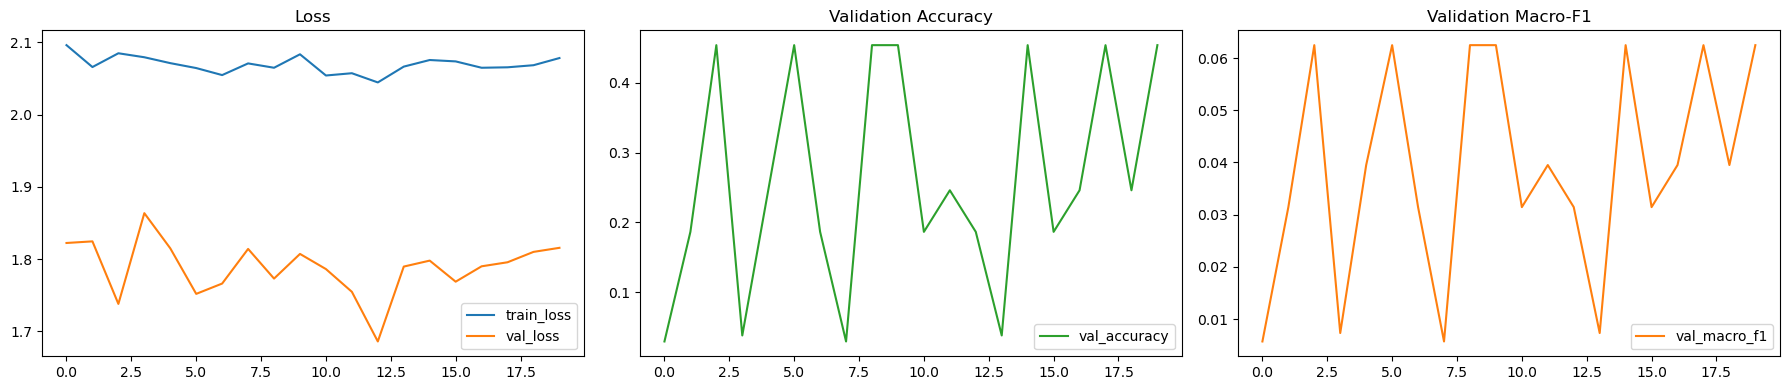

In [6]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_accuracy"], label="val_accuracy", color="tab:green")
axes[1].set_title("Validation Accuracy")
axes[1].legend()

axes[2].plot(history["val_macro_f1"], label="val_macro_f1", color="tab:orange")
axes[2].set_title("Validation Macro-F1")
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# Evaluate the best in-memory model on the test split
if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = evaluate_model(model, test_loader, device, num_classes=len(labels))
print("Test metrics:")
for key, value in test_metrics.items():
    if key == "confusion_matrix":
        continue
    print(f"  {key}: {value:.6f}" if isinstance(value, float) else f"  {key}: {value}")


Test metrics:
  accuracy: 0.457759
  macro_precision: 0.045776
  macro_recall: 0.100000
  macro_f1: 0.062803
  loss: 1.732677


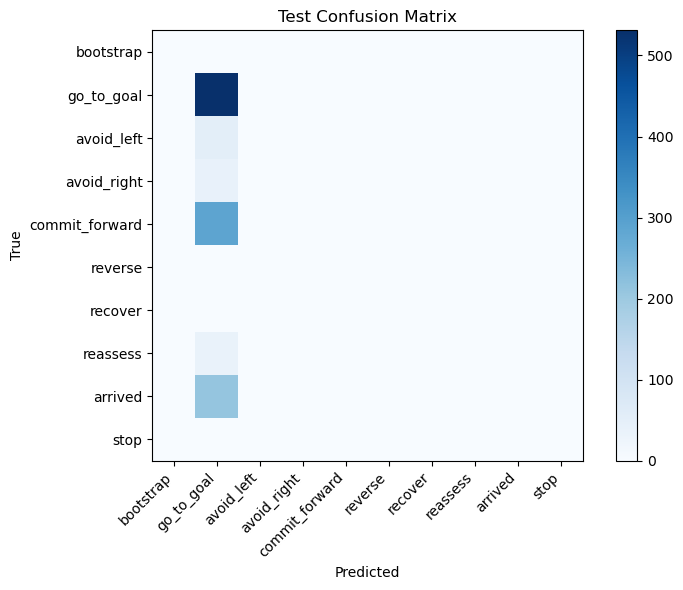

In [8]:
# Optional: inspect the confusion matrix after the run
cm = test_metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Confusion Matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

cm = test_metrics["confusion_matrix"]

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(cm_df.to_string())

                bootstrap  go_to_goal  avoid_left  avoid_right  commit_forward  reverse  recover  reassess  arrived  stop
bootstrap               0           0           0            0               0        0        0         0        0     0
go_to_goal              0         531           0            0               0        0        0         0        0     0
avoid_left              0          53           0            0               0        0        0         0        0     0
avoid_right             0          39           0            0               0        0        0         0        0     0
commit_forward          0         287           0            0               0        0        0         0        0     0
reverse                 0           1           0            0               0        0        0         0        0     0
recover                 0           2           0            0               0        0        0         0        0     0
reassess                